In [49]:
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

In [50]:
import distill.taskflow as taskflow
from pathlib import Path
from distill.configuration_file import config

In [51]:
opt=config(r"distill/config_with_attention_head.json")

In [52]:
from distill.taskflow import *

In [53]:
import torch

In [54]:
model = taskflow.FPI(opt, device="cpu")

In [55]:
ckpt = torch.load(r"D:\CrossGeoLoc_clear_version\for_us\checkpoints\net_best.pth", map_location="cpu")

In [56]:
model_keys = set(model.state_dict().keys())
ckpt = torch.load(r"D:\CrossGeoLoc_clear_version\for_us\checkpoints\net_best.pth", map_location="cpu")
new_state_dict = {}
for k, v in ckpt.items():
    # вариант без префикса
    if k in model_keys:
        new_state_dict[k] = v
    # вариант с префиксом
    elif "backbone_uav.backbone." + k in model_keys:
        new_state_dict["backbone_uav.backbone." + k] = v
    else:
        print("SKIP:", k)

missing, unexpected = model.load_state_dict(new_state_dict, strict=True)

print("missing:", missing)
print("unexpected:", unexpected)

missing: []
unexpected: []


In [57]:
print(list(ckpt.keys())[:10])
print(list(model.state_dict().keys())[:10])

['backbone_uav.backbone.cls_token', 'backbone_uav.backbone.pos_embed', 'backbone_uav.backbone.patch_embed.proj.weight', 'backbone_uav.backbone.patch_embed.proj.bias', 'backbone_uav.backbone.blocks.0.norm1.weight', 'backbone_uav.backbone.blocks.0.norm1.bias', 'backbone_uav.backbone.blocks.0.attn.qkv.weight', 'backbone_uav.backbone.blocks.0.attn.qkv.bias', 'backbone_uav.backbone.blocks.0.attn.proj.weight', 'backbone_uav.backbone.blocks.0.attn.proj.bias']
['backbone_uav.backbone.cls_token', 'backbone_uav.backbone.pos_embed', 'backbone_uav.backbone.patch_embed.proj.weight', 'backbone_uav.backbone.patch_embed.proj.bias', 'backbone_uav.backbone.blocks.0.norm1.weight', 'backbone_uav.backbone.blocks.0.norm1.bias', 'backbone_uav.backbone.blocks.0.attn.qkv.weight', 'backbone_uav.backbone.blocks.0.attn.qkv.bias', 'backbone_uav.backbone.blocks.0.attn.proj.weight', 'backbone_uav.backbone.blocks.0.attn.proj.bias']


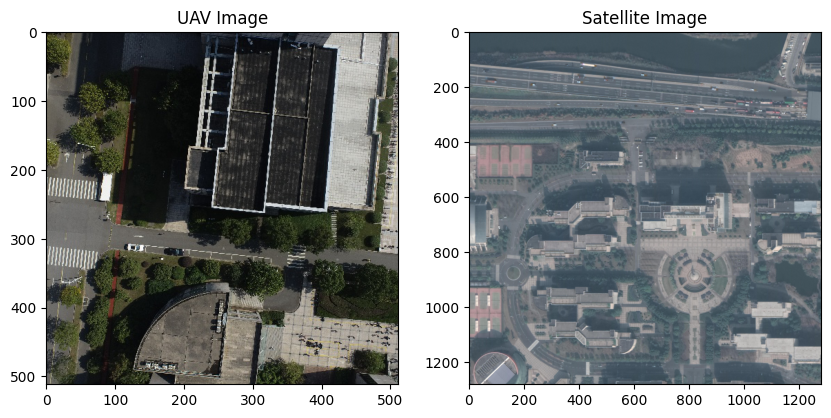

In [58]:
# For demonstration, load sample images
# Replace with actual paths to UAV and satellite images
uav_image_path = r'map2019\train\Caijing_000009\UAV\0.JPG'  # Example path
satellite_image_path = r'map2019\train\Caijing_000009\Satellite\0.tif'  # Example path

# Load images
uav_image = Image.open(uav_image_path)
satellite_image = Image.open(satellite_image_path)

# Display images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(uav_image)
plt.title('UAV Image')
plt.subplot(1, 2, 2)
plt.imshow(satellite_image)
plt.title('Satellite Image')
plt.show()

In [59]:
import json
import os


In [60]:
satellite_path=r'map2019\val\Chuanmei_100_000004\Satellite\0.jpg'

In [61]:
Path(satellite_path.split(r"\Satellite")[0]).joinpath("GPS_info.json")

WindowsPath('map2019/val/Chuanmei_100_000004/GPS_info.json')

In [62]:
import torch
from torchvision import transforms
from PIL import Image

In [63]:
def get_transformer(config):
    transform_uav_list = [
        transforms.Resize(opt.data_config["UAVhw"], interpolation=3),
        transforms.ToTensor()
    ]

    transform_satellite_list = [
        transforms.Resize(
            opt.data_config["Satellitehw"], interpolation=3),
        transforms.ToTensor()
    ]

    data_transforms = {
        'UAV': transforms.Compose(transform_uav_list),
        'satellite': transforms.Compose(transform_satellite_list)
    }

    return data_transforms

In [64]:
transform=get_transformer(config=opt)

In [65]:
x=transform['UAV'](uav_image)

In [66]:
z=transform['satellite'](satellite_image)

In [67]:
model.eval()

FPI(
  (backbone_uav): Backbone(
    (backbone): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=384, out_features=1152, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=384, out_features=384, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (

In [68]:
z = z.unsqueeze(0)  # если z имеет форму [3, 192, 192]
x = x.unsqueeze(0)  # если x имеет форму [3, 576, 576]

In [69]:
output=model(x,z)

In [70]:
normalized = torch.sigmoid(torch.tensor(output[0][0])).squeeze().detach().numpy()

C:\Users\polur\AppData\Local\Temp\ipykernel_6560\2907845040.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  normalized = torch.sigmoid(torch.tensor(output[0][0])).squeeze().detach().numpy()


In [73]:
def create_hanning_mask(center_R):
    hann_window = np.outer(  # np.outer 如果a，b是高维数组，函数会自动将其flatten成1维 ，用来求外积
        np.hanning(center_R+2),
        np.hanning(center_R+2))
    hann_window /= hann_window.sum()
    return hann_window[1:-1, 1:-1]

In [ ]:
import cv2

In [74]:
kernel = create_hanning_mask(51)

In [75]:
map = cv2.filter2D(normalized, -1, kernel)

In [80]:
pos = np.argmax(map)

In [79]:
coords = np.unravel_index(pos, map.shape)

In [81]:
coords

(np.int64(298), np.int64(278))

In [82]:
with Image.open(satellite_image_path) as img:
    height=img.height
    width=img.width

In [85]:
height, width

(1280, 1280)

In [86]:
x_original, y_original

(np.float64(662.2222222222223), np.float64(617.7777777777778))

In [83]:
x_original = (coords[0] / 576) * height
y_original = (coords[1] / 576) * width

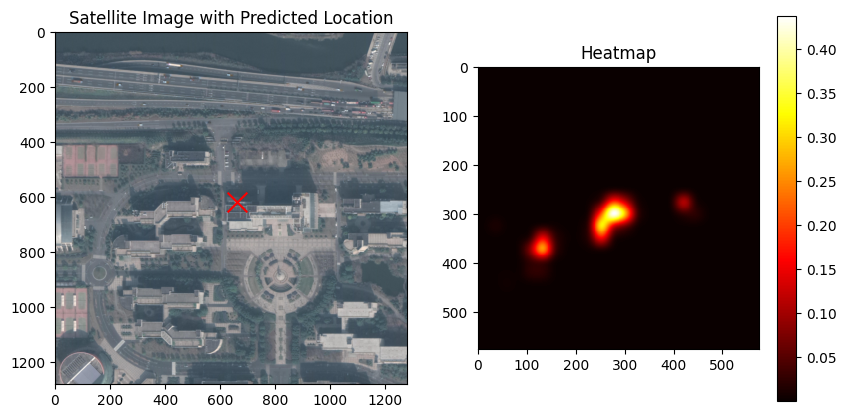

In [84]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(satellite_image)
plt.scatter(x_original, y_original, color='red', s=200, marker='x')
plt.title('Satellite Image with Predicted Location')

plt.subplot(1, 2, 2)
plt.imshow(map, cmap='hot', interpolation='nearest')
plt.title('Heatmap')
plt.colorbar()
plt.show()